# **Практическая работа №5. Архитектуры CNN и Transfer Learning.ipynb**

## **Задание 1. Использование предобученной модели**

### **1.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/**

In [ ]:
# Ваш код
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB4

model = EfficientNetB4(weights='imagenet')
model.summary()

78864416/78864416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 380, 380,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 380, 380,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 380, 380,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 380, 380,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 381, 381,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 190, 190,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 190, 190,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 190, 190,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 190, 190,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 190, 190,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 190, 190,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 190, 190,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 190, 190,  │      1,152 │ block1a_se_excit

 Total params: 19,466,823 (74.26 MB)

 Trainable params: 19,341,616 (73.78 MB)

 Non-trainable params: 125,207 (489.09 KB)

### **1.2. Загрузите из сети Интернет 5 изображений с разными классами, из тех, что приведены в [списке](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a), и сохраните их представление в список images**

In [ ]:
# Ваш код
from google.colab import files
uploaded = files.upload()

Saving flamingo.jpg to flamingo.jpg
Saving great grey owl.jpg to great grey owl.jpg
Saving green mamba.jpg to green mamba.jpg
Saving tree frog.jpg to tree frog.jpg
Saving white stork.jpg to white stork.jpg


In [ ]:
import cv2
paths = [
    "/content/flamingo.jpg",
    "/content/great grey owl.jpg",
    "/content/green mamba.jpg",
    "/content/tree frog.jpg",
    "/content/white stork.jpg"
]

images = []
for path in paths:
  img = cv2.imread(path)
  images.append(img)

Image 0, shape: (200, 252, 3)


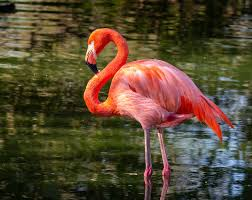

Image 1, shape: (163, 309, 3)


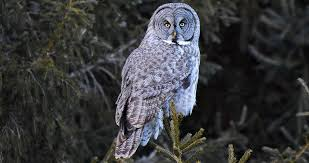

Image 2, shape: (225, 225, 3)


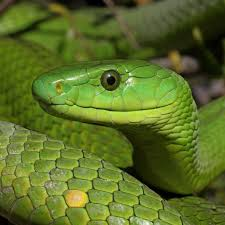

Image 3, shape: (191, 264, 3)


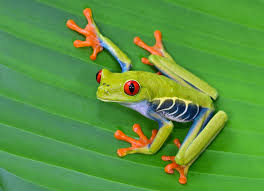

Image 4, shape: (675, 900, 3)


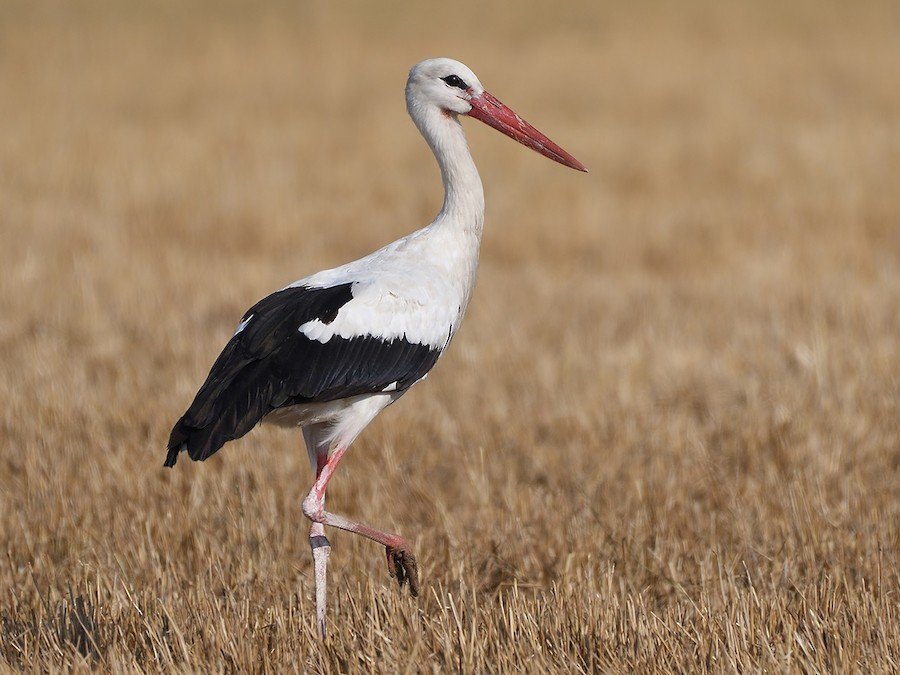

In [ ]:
from google.colab.patches import cv2_imshow

for i, img in enumerate(images):
    print(f"Image {i}, shape: {img.shape}")
    cv2_imshow(img)

### **1.3. Напишите функцию, принимающую на вход список с исходными изображениями и возвращающую список с преобразованными изображениями под формат входных данных выбранной Вами модели СНС (нормализация).**

(Не забудьте создать независимую копию исходного списка в теле функции, для обработки именно независимой копии, а не оригинального списка)

In [ ]:
# Ваш код
import numpy as np
import cv2
from tensorflow.keras.applications.efficientnet import preprocess_input

processed_images = []

for img in images:
    # Копия изображения
    img_copy = img.copy()

    # Resize
    img_resized = cv2.resize(img_copy, (380, 380))

    # BGR в RGB
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    img_array = np.array(img_rgb, dtype=np.float32)

    # Preprocess
    img_preprocessed = preprocess_input(img_array)

    # 6. Добавляем batch dimension
    img_batch = np.expand_dims(img_preprocessed, axis=0)

    processed_images.append(img_batch)

In [ ]:
print(len(processed_images))
print(processed_images[0].shape)

5
(1, 380, 380, 3)


### **1.5. Выведите изображения и соответствующие им классы (как в примере из теории)**

In [ ]:
for i in range(len(processed_images)):
  res = model.predict(processed_images[i])

  print("Class index:", np.argmax(res))

  decoded = decode_predictions(res, top=3)[0]
  for label in decoded:
      print(label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step
Class index: 130
('n02007558', 'flamingo', np.float32(0.7596293))
('n02493509', 'titi', np.float32(0.0018916794))
('n01443537', 'goldfish', np.float32(0.0013381293))
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step
Class index: 24
('n01622779', 'great_grey_owl', np.float32(0.8417399))
('n01608432', 'kite', np.float32(0.0022687216))
('n02100236', 'German_short-haired_pointer', np.float32(0.0013430788))
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step
Class index: 64
('n01749939', 'green_mamba', np.float32(0.82498175))
('n01729977', 'green_snake', np.float32(0.0072581084))
('n01739381', 'vine_snake', np.float32(0.0032930402))
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 776ms/step
Class index: 31
('n01644373', 'tree_frog', np.float32(0.46265435))
('n01644900', 'tailed_frog', np.float32(0.30914715))
('n01641577', 'bullfrog', np.float32(0.005590195))
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 877ms/step
Class index: 127
('n02002556', 'white_stork', np.float32(0.7021891))
('n02002724', 'black_stork', np

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Image 0


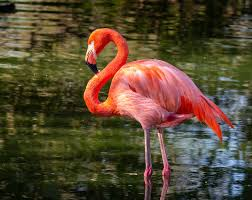

Predictions:
1. flamingo: 0.7596
2. titi: 0.0019
3. goldfish: 0.0013
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step

Image 1


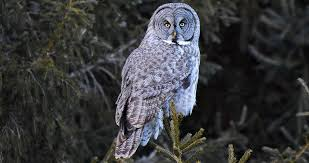

Predictions:
1. great_grey_owl: 0.8417
2. kite: 0.0023
3. German_short-haired_pointer: 0.0013
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step

Image 2


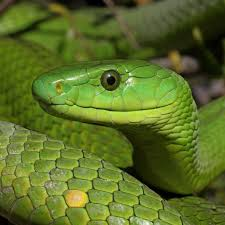

Predictions:
1. green_mamba: 0.8250
2. green_snake: 0.0073
3. vine_snake: 0.0033
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step

Image 3


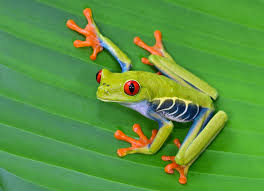

Predictions:
1. tree_frog: 0.4627
2. tailed_frog: 0.3091
3. bullfrog: 0.0056
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step

Image 4


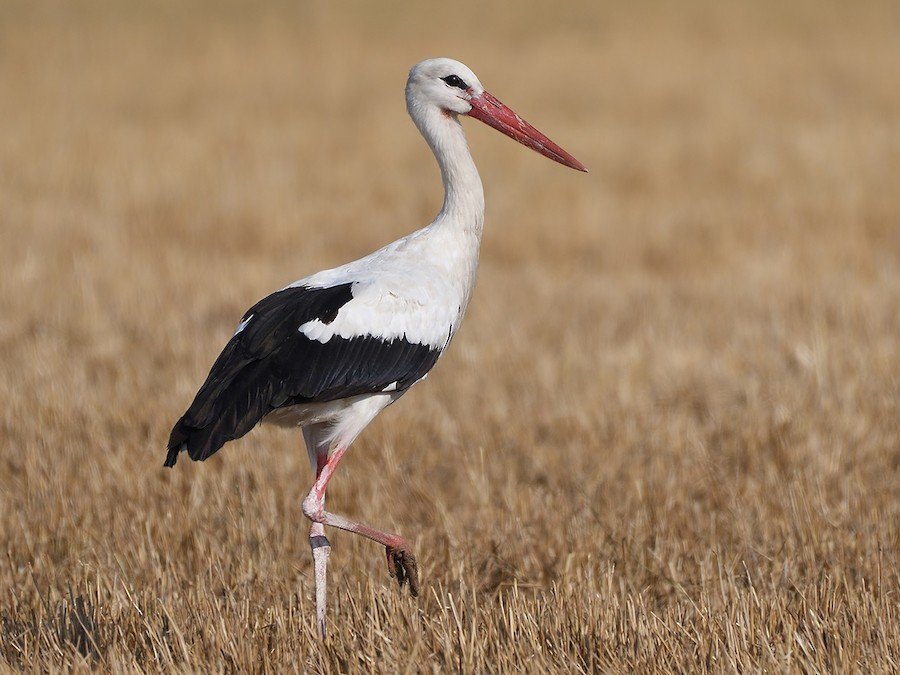

Predictions:
1. white_stork: 0.7022
2. black_stork: 0.0380
3. crane: 0.0027


In [ ]:
import numpy as np
from tensorflow.keras.applications.efficientnet import decode_predictions
from google.colab.patches import cv2_imshow
import cv2

for i, img in enumerate(processed_images):
    # Предсказание
    preds = model.predict(img)

    # Декодирование
    decoded = decode_predictions(preds, top=3)[0]

    # Вывод изображения
    print(f"\nImage {i}")
    cv2_imshow(images[i])

    # Предсказания
    print("Predictions:")
    for j, (imagenet_id, label, prob) in enumerate(decoded):
        print(f"{j+1}. {label}: {prob:.4f}")

## **Задание 2. Использование обученной модели для работы со своим датасетом**

### **2.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/**

In [ ]:
import tensorflow as tf
help(tf.keras.applications)

Help on package keras.applications in keras:

NAME
    keras.applications - DO NOT EDIT.

DESCRIPTION
    This file was autogenerated. Do not edit it by hand,
    since your modifications would be overwritten.

PACKAGE CONTENTS
    convnext (package)
    densenet (package)
    efficientnet (package)
    efficientnet_v2 (package)
    imagenet_utils (package)
    inception_resnet_v2 (package)
    inception_v3 (package)
    mobilenet (package)
    mobilenet_v2 (package)
    mobilenet_v3 (package)
    nasnet (package)
    resnet (package)
    resnet50 (package)
    resnet_v2 (package)
    vgg16 (package)
    vgg19 (package)
    xception (package)

FILE
    /usr/local/lib/python3.12/dist-packages/keras/applications/__init__.py




In [ ]:
# Ваш код
from tensorflow.keras.applications import EfficientNetB4

base_model = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(380, 380, 3)
)
base_model.summary()

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "efficientnetb4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 380, 380,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 380, 380,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 380, 380,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 380, 380,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 381, 381,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 190, 190,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 190, 190,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 190, 190,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 190, 190,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 190, 190,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 190, 190,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 190, 190,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 190, 190,  │      1,152 │ block1a_se_excit

 Total params: 17,673,823 (67.42 MB)

 Trainable params: 17,548,616 (66.94 MB)

 Non-trainable params: 125,207 (489.09 KB)

### **2.2. Подготовка тренировочных данных. Разделение на обучающую и тестовую выборку**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Ваш код
import tensorflow as tf

dataset_path = "/content/drive/MyDrive/ПР-3/Dataset"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(380, 380),
    batch_size=16
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(380, 380),
    batch_size=16
)

Found 2772 files belonging to 3 classes.
Using 2218 files for training.
Found 2772 files belonging to 3 classes.
Using 554 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['Asian Green Bee-Eater', 'Brown-Headed Barbet', 'Common Kingfisher']


### **2.3. Обучение своей модели на основе предобученной модели** "*название модели, выбранной в п.2.1.*"

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
base_model.trainable = False

In [ ]:
from tensorflow.keras import layers, models

inputs = tf.keras.Input(shape=(380, 380, 3))

# preprocessing
x = layers.Rescaling(1./255)(inputs)

# база
x = base_model(x, training=False)

# голова
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(3, activation='softmax')(x)

my_model = models.Model(inputs, outputs)

In [ ]:
# Ваш код
from tensorflow.keras.optimizers import Adam
my_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

In [ ]:
history = my_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4098 - loss: 1.2063
Epoch 1: val_accuracy improved from None to 0.33755, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 916s 6s/step - accuracy: 0.4026 - loss: 1.1802 - val_accuracy: 0.3375 - val_loss: 1.0849 - learning_rate: 1.0000e-04
Epoch 2/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.4437 - loss: 1.1126
Epoch 2: val_accuracy improved from 0.33755 to 0.50903, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 50s 356ms/step - accuracy: 0.4459 - loss: 1.0968 - val_accuracy: 0.5090 - val_loss: 1.0600 - learning_rate: 1.0000e-04
Epoch 3/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.4317 - loss: 1.1054
Epoch 3: val_accuracy improved from 0.50903 to 0.53610, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
139/139 ━━━━━━━━━━━━━━

### **2.4. Визуализация процесса обучения модели**

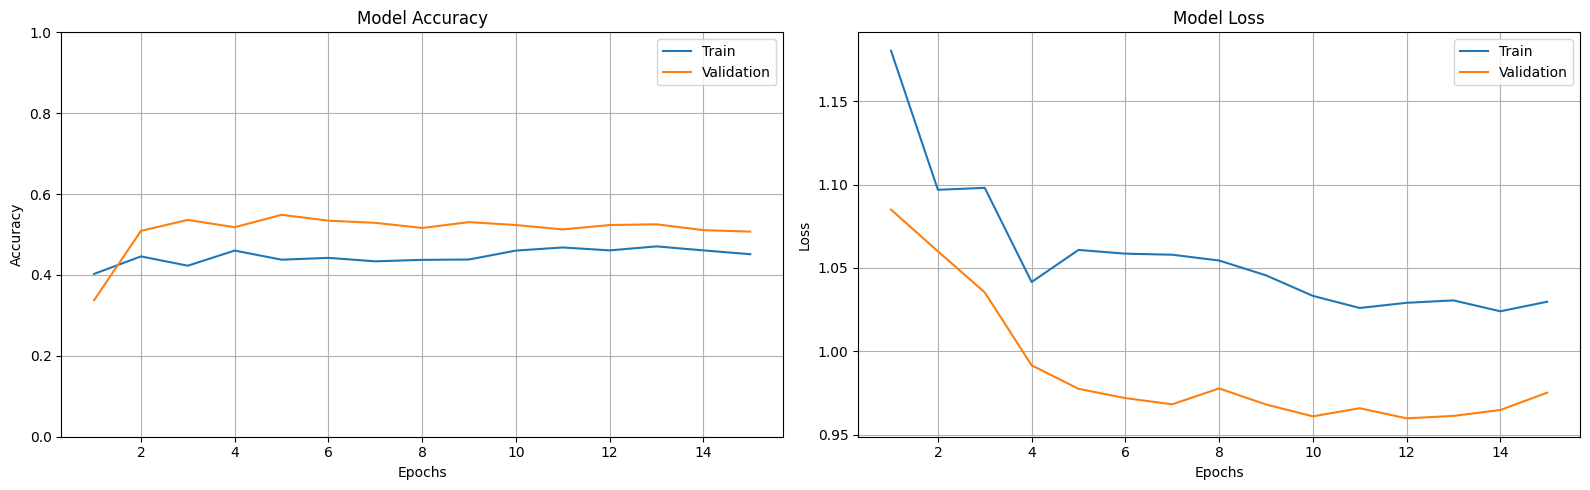

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

epochs_range = range(1, len(history.history['accuracy']) + 1)

#  Accuracy
ax1.plot(epochs_range, history.history['accuracy'], label='Train')
ax1.plot(epochs_range, history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(True)

#  Loss
ax2.plot(epochs_range, history.history['loss'], label='Train')
ax2.plot(epochs_range, history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### **2.5. Подготовьте набор проверочных данных (examples)**

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/best_model.keras')

In [ ]:
import numpy as np

examples = []
true_labels = []

for images, labels in val_ds.take(1):
    examples = images
    true_labels = labels

In [ ]:
preds = model.predict(examples)
pred_classes = np.argmax(preds, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step


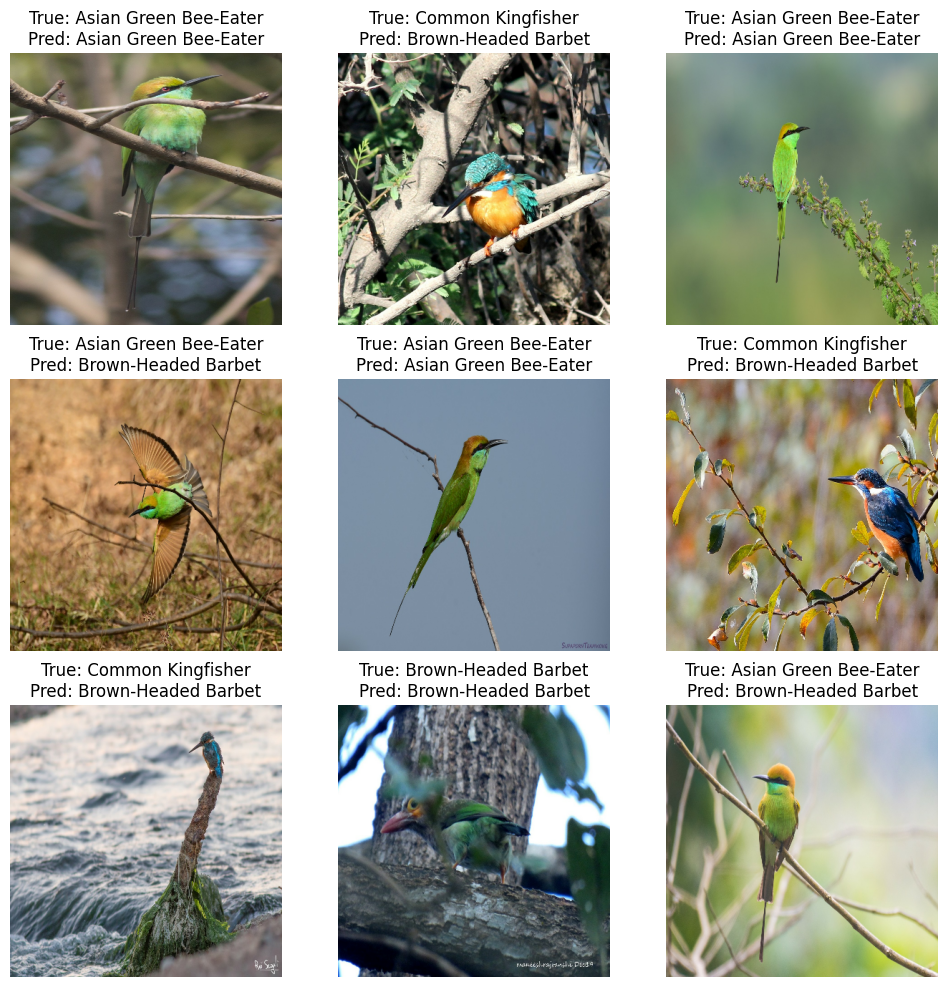

In [ ]:
# Ваш код
import matplotlib.pyplot as plt

class_names = ['Asian Green Bee-Eater', 'Brown-Headed Barbet', 'Common Kingfisher']

plt.figure(figsize=(12, 12))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(examples[i].numpy().astype("uint8"))

    true_label = class_names[true_labels[i]]
    pred_label = class_names[pred_classes[i]]

    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.show()

### **2.6. Реализуйте графический интерфейс для взаимодействия с обученной моделью, используя [Gradio](https://www.gradio.app/guides/image-classification-in-tensorflow) или люое другое решение.**



Если выбрали Gradio, то в качестве примеров (параметр examples в Gradio), используйте изображения из списка images (п.1.2.)

In [ ]:
!pip install gradio

In [ ]:
import numpy as np
import cv2
from PIL import Image

def predict_image(img):
    img = np.array(img)
    img = cv2.resize(img, (380, 380))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    preds = model.predict(img)[0]

    return {
        class_names[i]: float(preds[i])
        for i in range(len(class_names))
    }

In [ ]:
# Ваш код
import gradio as gr

interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs="label",
    title="Bird Classifier",
    description="Загрузи изображение птицы"
)

In [ ]:
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4122029612daf4d4ad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## **Задание 3. Классификация набора пространственных данных EuroSat (для магистров)**

- Ссылка на датасет: https://github.com/phelber/eurosat

- Описание на kaggle: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset

В этом задании Вам будет предоставлен набор данных EuroSat, который содержит снимки земной поверхности, снятые спутником Sentinel-2. Вам нужно будет обучить модель для классификации этих изображений на 10 классов, представляющих различные типы земного покрова.

### **3.1. Загрузка данных:**
  * [Скачайте](https://madm.dfki.de/files/sentinel/EuroSAT.zip) набор данных EuroSat
  * Разделите данные на обучающую, валидационную и тестовую выборки.



In [7]:
!wget --no-check-certificate https://madm.dfki.de/files/sentinel/EuroSAT.zip

--2026-04-08 08:30:11--  https://madm.dfki.de/files/sentinel/EuroSAT.zip
Resolving madm.dfki.de (madm.dfki.de)... 131.246.195.183
Connecting to madm.dfki.de (madm.dfki.de)|131.246.195.183|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 94280567 (90M) [application/zip]
Saving to: ‘EuroSAT.zip’

EuroSAT.zip         100%[===================>]  89.91M  18.0MB/s    in 6.3s    

2026-04-08 08:30:18 (14.2 MB/s) - ‘EuroSAT.zip’ saved [94280567/94280567]



In [8]:
# Ваш код
import zipfile

with zipfile.ZipFile("EuroSAT.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/eurosat")


In [19]:
import tensorflow as tf
dataset_path = "/content/eurosat/2750"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=16
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=16
)

Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.


In [20]:
class_names = train_ds.class_names
print(class_names)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


### **3.2. Выбор архитектуры нейронной сети:**
  * Выберите архитектуру нейронной сети, основанную на трансферном обучении, например, ResNet50, VGG16 или InceptionV3 ([полный список](https://keras.io/api/applications/)).
  * Загрузите предобученную модель выбранной архитектуры.


In [21]:
# Ваш код
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### **3.3. Дообучение модели:**
  * Добавьте к предобученной модели несколько слоев для классификации изображений EuroSat.
  * Обучите модель на обучающей выборке.

In [22]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications.resnet50 import preprocess_input

inputs = tf.keras.Input(shape=(224, 224, 3))

x = preprocess_input(inputs)

# базовая модель
x = base_model(x, training=False)

# классификатор
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs, outputs)

In [24]:
# Ваш код
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/100
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6734 - loss: 1.0443
Epoch 1: val_loss improved from None to 0.18268, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 105s 68ms/step - accuracy: 0.7908 - loss: 0.6525 - val_accuracy: 0.9369 - val_loss: 0.1827 - learning_rate: 1.0000e-04
Epoch 2/100
1349/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8862 - loss: 0.3483
Epoch 2: val_loss improved from 0.18268 to 0.14814, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 84s 62ms/step - accuracy: 0.8929 - loss: 0.3312 - val_accuracy: 0.9494 - val_loss: 0.1481 - learning_rate: 1.0000e-04
Epoch 3/100
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9097 - loss: 0.2702
Epoch 3: val_loss improved from 0.14814 to 0.13409, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1350/1350 ━━━━━━━━━━━━━



### **3.4. Оценка модели:**
  * Оцените производительность модели на валидационной и тестовой выборках.
  * Сравните результаты с другими архитектурами нейронных сетей.



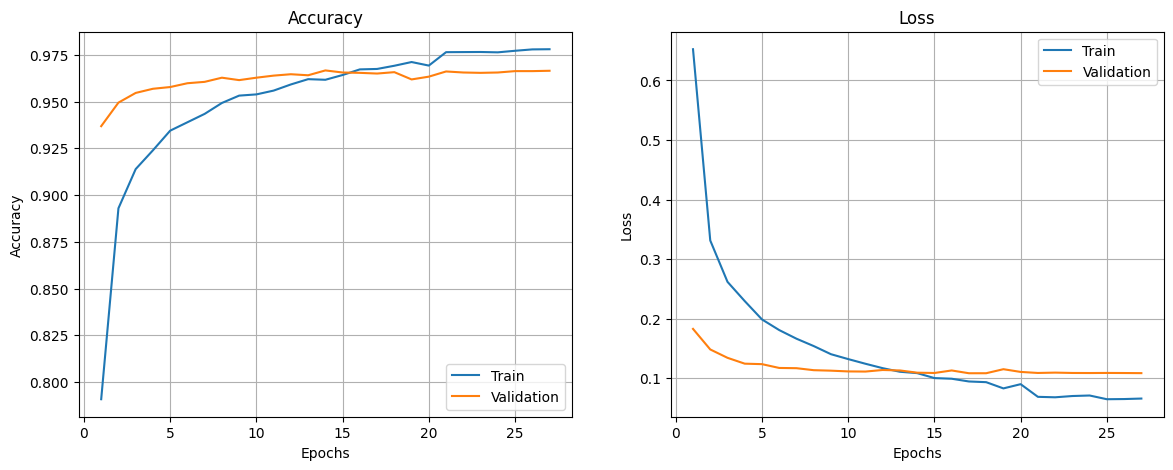

In [26]:
# Ваш код
import matplotlib.pyplot as plt

epochs_range = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Train')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Train')
plt.plot(epochs_range, history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

В ходе работы были использованы различные архитектуры нейронных сетей: EfficientNetB4 и ResNet50. Модель EfficientNetB4 показала хорошие результаты на задаче классификации изображений птиц, однако обучение происходило медленнее из-за более сложной архитектуры. Модель ResNet50, применённая к датасету EuroSAT, продемонстрировала более высокую точность (до 96–97%) и более стабильное обучение. Это связано как с особенностями архитектуры, так и с характером данных. В целом обе модели показали высокую эффективность при использовании подхода transfer learning, однако ResNet50 оказалась более простой в обучении и менее ресурсоёмкой.


### **3.5. Анализ результатов:**
  * Проанализируйте влияние различных параметров на производительность модели, таких как:
      * Количество эпох обучения
      * Размер пакета
      * Функция активации
      * Оптимизатор
      * Регуляризация

-----------------------------------------
**Ваш вывод**
-----------------------------------------


Количество эпох обучения оказывает существенное влияние на качество модели. При увеличении числа эпох наблюдается рост точности на обучающей выборке, однако после определённого момента улучшение замедляется, а при слишком большом числе эпох может возникнуть переобучение.

Размер пакета (batch size) влияет на стабильность и скорость обучения. При использовании небольшого размера пакета обучение становится более шумным, но может улучшить обобщающую способность модели. Большие значения batch size ускоряют обучение, однако могут привести к ухудшению качества. В работе был выбран batch size = 16 как оптимальный баланс между скоростью и качеством.

Функция активации играет важную роль в обучении нейронной сети. В данной работе использовалась функция ReLU в скрытых слоях, которая обеспечивает эффективное обучение и предотвращает проблему затухающих градиентов. В выходном слое использовалась функция softmax, подходящая для задачи многоклассовой классификации.

Выбор оптимизатора также существенно влияет на результат. Использование оптимизатора Adam позволило добиться быстрой сходимости и стабильного обучения.

Регуляризация применяется для предотвращения переобучения. В данной работе использовался слой Dropout, который случайным образом отключает нейроны во время обучения.

Таким образом, корректный выбор гиперпараметров является ключевым фактором успешного обучения нейронной сети и позволяет достичь высокой точности классификации.